# Executive Summary

## Context and Scope
This report analyzes the crucial relationship between state-level resource devotion to public education and corresponding student outcomes across the United States. Utilizing data from the School Finance Indicators Database (SFID) and the National Assessment of Educational Progress (NAEP), this analysis provides an evidence-based assessment of where resources effective. The U.S. public education system serves approximately 83% of school-aged children, making the efficacy of its funding and resource models a critical national concern.

## Key Findings
The analysis reveals that while the correlation between state resource levels and overall student outcomes is complex, a significant link exists between adjusted per-pupil spending and measurable student achievement.

* **Performance Variation:** There is a significant difference between assessment scores for students with lower socioeconomic status and middle and higher socioeconomic status. The differences increase as students progress through years of school in the math assessment, but the difference decreases for the reading assessment.

* **High and Low Achieving States:** The group of states that performed above the national average consistently are CO, IN, MA, MN, ND, NH, NJ, PA, UT, WI, and MT, while the group of states that consistently performed worse than the national average are AL, AR, AZ, CA, DC, GA, LA, NM, RI, WV, AK, NV, and IL.

* **Finance Indicator Correlations:** There is a positive and strong correlation between state and local revenue per pupil and a state's assessment scores, up to a certain funding level. Smaller yet significant correlations are found between the fairness of spending on education and staffing ratios with assessment scores.

## Recommendations
To guide future policy and resource allocation decisions, the following actions are recommended:

* **Targeted Interventions:** Math interventions for students with lower socioeconomic status will significantly help improve national educational equity.

* **Expanded Analysis:** Future research should extend beyond 4th Grade Math to explore correlations across additional grades and subject areas. Further investigation into specific finance variables, such as teacher compensation and retention metrics, is necessary to fully analyze the impact of resources on outcomes.

* **Contextual Comparison:** A segmented analysis comparing public and private educational outcomes should be undertaken to provide a more comprehensive view of the entire K-12 landscape and mitigate potential omitted variable bias.

## Conclusion
The future success of the U.S. public education system is  linked to thoughtful, data-guided decisions regarding resource allocation. By focusing on evidence-based strategies, the nation can improve educational outcomes and life chances for all students.


# Introduction & Methodology


The U.S. education system is a key component of American society, having educated generations of workers, innovators, and leaders. Teachers across the country are pouring into youth to help them think critically, read analytically, and dream passionately. About [83% of school aged children attend public schools](https://www.pewresearch.org/short-reads/2024/06/06/us-public-private-and-charter-schools-in-5-charts/), demonstrating that the effectiveness and quality of this system can have a far reaching impact on our economy and society.

This system, however, is not reaching its full potential. Its quality is not equally distributed, leaving gaps in performance that can be seen across a student's characteristics, such as being economically disadvantaged, or belonging to a certain demographic. When students are not given an adequate education to flourish, there is lost opportunity for our society to flourish as well.

Since education is mostly funded and managed at the state level, it can be interesting to observe differences in outcomes and resources between states.

This report analyzes data from the National Assessment of Educational Product (NAEP) from the Department of Education, also known as "The Nation's Report Card", in order to compare achievement levels on a baseline test across states in the U.S. The test is administered every couple of years to a representative sample of students, with a sample size of ~10,000 students.

In addition to student outcomes in each state, certain financial indicators are analyzed from the School Finance Indicators Database (SFID), developed in partnership with the Albert Shanker Institute, The University of Miami School of Education & Human Development, and the Rutgers Graduate School of Education. These indicators have been systematically developed to measure a state's revenue and spending, teacher salaries, staffing ratios, as well as a measure of "fairness" depending on how these resources are distributed across district poverty levels.

While there are many complex factors that determine a state's outcome and funding ability, this analysis hopes to identify some potential areas of focus for further analysis and future investment to improve the U.S. education system for all Americans.

# Analysis

In [ ]:
# The following packages are required for the analysis in this workbook
import requests
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

## Access Data

To begin, the relevant connections are made to the two sources of data (NAEP and SFID).

### National Assessment of Educational Progress

First, a couple of helper functions are created to access the NAEP data through its API with various query parameters. These functions were used in the creation of the report, but are not currently activated in this workbook. There were issues with loading times that caused queries to fail. For the ease of the reader, the resulting datasets are retrieved from github links.

In [ ]:
def connect_NAEP_API(query):
  """Retrieve data from the NCES Nations Report Card using their API.
  Visit https://www.nationsreportcard.gov/api_documentation.aspx for specific
  details.

  Required packages:
    pandas as pd
    requests

  Args:
    query: str, url-style string of query parameters

  Returns:
    data_df: DataFrame of results from query

  """

  base_url = "https://www.nationsreportcard.gov"
  resource_path = "/DataService/GetAdhocData.aspx"
  url = base_url + resource_path + query
  response = requests.get(url)
  if response.status_code == 200:
    response_json = pd.json_normalize(response.json())
    data_df = pd.DataFrame(response_json["result"].iloc[0])
    return data_df
  else:
    # sometimes can return json, other times it does not
    # this method captures and displays all errors
    print(response.text)
    return None

In [ ]:
def get_education_statistics(type_, subject, cohort, subscale, variable, jurisdiction,
                             stattype, year, comparisonvalues=""):
  """Retrieve data from the NCES Nations Report Card using their API.
  Visit https://www.nationsreportcard.gov/api_documentation.aspx for specific
  details.

  Required packages:
    pandas as pd
    requests

  Args:
    type_: str, what kind of data to return
    subject: str, mathematics or reading
    cohort: str, 1, 2, or 3 for grades 4, 8, or 12 respectively
    subscale: str, subscale of subject
    variable: str, student demographic groups or survey question variable
    jurisdiction: str, national, state, and district
    stattype: different type of statistical estimates (mean, standard dev,
      row percentage, percentiles)
    year: str, year of assessment
    comparisonvalues: str, (optional) choose specific variable cateogories
      (e.g. 1 for male, 2 for female)

  Returns:
    data_df: DataFrame of results from query
  """
  base_url = "https://www.nationsreportcard.gov"
  resource_path = "/DataService/GetAdhocData.aspx"
  if comparisonvalues != "":
    query = f"?type={type_}&subject={subject}&cohort={cohort}&subscale={subscale}&variable={variable}&comparisonvalues={comparisonvalues}&jurisdiction={jurisdiction}&stattype={stattype}&Year={year}"
  else:
    query = f"?type={type_}&subject={subject}&cohort={cohort}&subscale={subscale}&variable={variable}&jurisdiction={jurisdiction}&stattype={stattype}&Year={year}"
  url = base_url + resource_path + query
  response = requests.get(url)
  if response.status_code == 200:
    response_json = pd.json_normalize(response.json())
    data_df = pd.DataFrame(response_json["result"].iloc[0])
    return data_df
  else:
    # sometimes can return json, other times it does not
    # this method captures and displays all errors
    print(response.text)
    return None

In [ ]:
# Create Cohort to Grade Dictionary
c_to_g = {1: 4, 2: 8, 3: 12}
# create list of subjects
subjects = ["mathematics", "reading"]

# Available Tests
# Note: years that have both assessments with and without accomodations, only
#       the assessment with accomodations is chosen.
available_tests = {"3": {"mathematics": {"1990R2": ["1990R2", "1992R2", "1996R2", "2000"],
                                        "2005R3": ["2005", "2009", "2013", "2015", "2019", "2024"]},
                      "reading": {"1992": ["1992R2", "1994R2", "1998", "2002",
                                  "2005", "2009", "2013", "2015", "2019", "2024"]}},
                   "2": {"mathematics": {"1990R2": ["1990R2", "1992R2", "1996R2", "2000",
                                                    "2005", "2009", "2013", "2015", "2019", "2024"]},
                         "reading": {"1992": ["1992R2", "1994R2", "1998", "2002", "2003",
                                     "2005", "2007", "2009", "2011", "2013", "2015", "2017", "2019", "2022", "2024"]}},
                   "1": {"mathematics": {"1990R2": ["1990R2", "1992R2", "1996R2", "2000",
                                                    "2005", "2009", "2013", "2015", "2019", "2024"]},
                         "reading": {"1992": ["1992R2", "1994R2", "1998", "2000", "2002", "2003",
                                     "2005", "2007", "2009", "2011", "2013", "2015", "2017", "2019", "2022", "2024"]}}
                   }

subscale_values = {"mathematics": {"1990R2": {"MRPCM": "Composite scale", "MRPS1": "Number properties and operations scale",
                                               "MRPS2": "Measurement scale", "MRPS3": "Geometry scale",
                                               "MRPS4": "Data analysis, statistics, and probability scale", "MRPS5": "Algebra scale"},
                                    "2005R3": {"MWPCM": "Composite scale", "MWPS1": "Number properties and operations scale",
                                               "MWPS2": "Measurement and geometry scale",
                                               "MWPS3": "Data analysis, statistics, and probability scale", "MWPS4": "Algebra scale"}},
                    "reading": {"1992": {"RRPCM": "Composite scale", "RRPS1": "Literary experience", "RRPS2": "Gain information scale",
                                "RRPS3": "Perform a task scale", "RRPS4": "Gain and use information scale"}}
                   }

From the website, the years of assessments ranges from 1990 to 2024. The range for scores for the reading and mathematics assessments are both [0, 500], however the scores of the two assessments should not be compared with one another.

### School Finance Indicators Database

Next, the comprehensive list of data from SFID is accessed.

In [ ]:
# Fetch Data
sfid_url = "https://www.schoolfinancedata.org/wp-content/uploads/2025/03/StateIndicatorsDatabase_2025.xlsx"
filename = "sfid_data.xlsx"
response = requests.get(sfid_url)
if response.status_code == 200:
  with open(filename, 'wb') as f:
    f.write(response.content)
  print(f"File '{filename}' downloaded successfully.")
else:
  print(f"Failed to download file. Status code: {response.status_code}")

sfid_df = pd.read_excel(filename, sheet_name="Data")
#sfid_df.to_csv("sfid_df.csv")

File 'sfid_data.xlsx' downloaded successfully.


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [ ]:
sfid_df["year"].describe()[["min", "max"]]

,year
min,1993.0
max,2022.0


From reviewing the output, this data set covers years 1993 to 2022. The column of state abbreviations (`stabbr`) will be saved for future use.

In [ ]:
# Create dictionary for all states
states = {}
for i in range(51):
  stabbr = sfid_df["stabbr"].iloc[i]
  state_name = sfid_df["state_name"].iloc[i]
  region4 = sfid_df["region4"].iloc[i]
  region9 = sfid_df["region9"].iloc[i]
  states[stabbr] = {state_name, region4, region9}

# Create dictionary for national scores used by NAEP
national = {"NT": ["National Total"],
            "NP": ["National Public"],
            "NR": ["National Private"]
            }

## Analyze Data

First, this report looks at the differences between assessments offered with accomodations and assessments offered without to see if any adjustments need to be made to the scores to compare the two sets over time. Next, to assess one of the potential factors that can influence academic achievement, the scores of students across different socieconomic statuses are compared. Finally, the general performance of states are grouped to see which states consistently perform above average, and which states perform below average.

Turning to the SFID data, the national averages of federal, state, and local revenue devoted to various district poverty levels are compared over time to understand how the nation distributes resources on average. Finally, various metrics for each state from the SFID data are compared to their respective achievement on the NAEP assessment to observe any patterns or correlations between resource allocation and outcomes.

### Difference between tests with accomodations and without

In 1996, the NAEP began to offer [accomodations](https://nces.ed.gov/nationsreportcard/about/accom_table.aspx) for certain students, such as extended time, additional breaks, and other strategies. In order to compare test scores from before and after accomodations were offered, the scores are compared between students who took the test with accomodations and the students who took the test without accomodations during the years both were administered.

Even if there is not a significant difference for the national average, it's possible that the accommodations benefited certain groups of students more than others. For example, the accomodations could be most beneficial to students from economically disadvantaged backgrounds, and thus these changes should be factored when doing future analysis.

In [ ]:
# Define groups for analysis
years_no_ac = {"mathematics": ["1996R2", "2000R2"], "reading": ["1998R2"]}
years_ac = {"mathematics": ["1996", "2000"], "reading": ["1998"]}
cohorts = ["1", "2", "3"]
subscale = {"mathematics": "MRPCM",
            "reading": "RRPCM"}
# Commented out due to lags in API. For project replication, the data will be
# downloaded from a csv on github.
"""
ac_comparison_ls = []
ac_ed_comparison_ls = []
for s in subjects:
  for c in cohorts:
    for y in range(len(years_no_ac[s])):
      years = f"{years_no_ac[s][y]},{years_ac[s][y]}"
      ac_comparison_ls.append(get_education_statistics("sigacrossyear", s, c,
                                                       subscale[s], "TOTAL", "NP",
                                                       "MN:MN", years))
      ac_ed_comparison_ls.append(get_education_statistics("sigacrossyear", s, c,
                                                          subscale[s], "SLUNCH3",
                                                          "NP", "MN:MN", years))
ac_comparison_df = pd.concat(ac_comparison_ls)
ac_ed_comparison_df = pd.concat(ac_ed_comparison_ls)
"""
# Read in data from github
ac_comparison_df = pd.read_csv("https://raw.githubusercontent.com/DLPsamuel/Education_Data_Project/refs/heads/main/ac_comparison_df.csv")
ac_ed_comparison_df = pd.read_csv("https://raw.githubusercontent.com/DLPsamuel/Education_Data_Project/refs/heads/main/ac_ed_comparison_df.csv")

In [ ]:
# save to csv
#ac_comparison_df.to_csv("ac_comparison_df.csv")
#ac_ed_comparison_df.to_csv("ac_ed_comparison_df.csv")

# Find % difference for accomodations (total)
ac_comparison_df["pct_diff"] = (ac_comparison_df["gap"]/ac_comparison_df["focalValue"]) * 100

# Find % difference for accomodations (economically disadvantaged)
ac_ed_comparison_df["pct_diff"] = (ac_ed_comparison_df["gap"]/ac_ed_comparison_df["focalValue"]) * 100

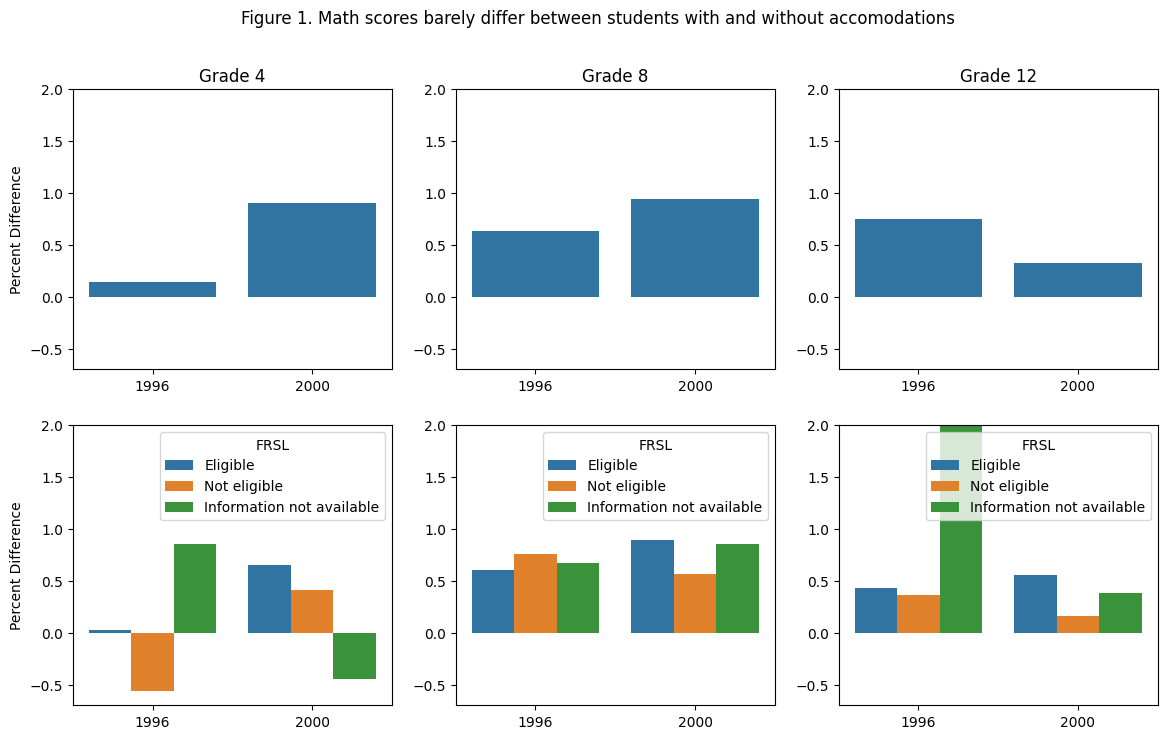

In [ ]:
# Plot the differences
h1 = 2
w1 = 3
fig1, ax1 = plt.subplots(h1, w1, figsize = (14, 8))

for i in range(h1):
  for j in range(w1):
    if i == 0:
      sns.barplot(data = ac_comparison_df.query(f"subject == 'MAT' and Cohort == {j + 1} and focalSample == 'R2'"),
                              x = "focalYear", y = "pct_diff", errorbar = None,
                              ax = ax1[i][j]
                              )
      ax1[i][j].set_title(f"Grade {c_to_g[j + 1]}")
      if j == 0:
        ax1[i][j].set_ylabel("Percent Difference")
      else:
        ax1[i][j].set_ylabel(None)
    else:
      plot1d = sns.barplot(data = ac_ed_comparison_df.query(f"subject == 'MAT' and Cohort == {j + 1} and focalSample == 'R2'"),
                              x = "focalYear", y = "pct_diff", hue = "valLabel",
                              ax = ax1[i][j]
                              )
      legend = ax1[i][j].get_legend()
      legend.set_title("FRSL")
      if j == 0:
        ax1[i][j].set_ylabel("Percent Difference")
      else:
        ax1[i][j].set_ylabel(None)
    ax1[i][j].set_xlabel(None)
    ax1[i][j].set_ylim(-.7, 2)

fig1.suptitle("Figure 1. Math scores barely differ between students with and without accomodations")
pass

Notes: FRSL stands for the "Free-/Reduced- School Lunch" program offered by the federal government, and is used as the indicator for whether a student is economically disadvantaged.

In [ ]:
# Find counts of significance
ac_comp_ratio = ac_comparison_df.query("focalSample == 'R2'").value_counts("sig")
ac_ed_comp_ratio = ac_ed_comparison_df.query("focalSample == 'R2'").value_counts("sig")

print("Table 1. Statistical significance of gap between test scores (accomodations)")
display(pd.merge(ac_comp_ratio, ac_ed_comp_ratio, on="sig", how="outer")
          .fillna(0).rename(columns={"count_x": "National Average",
                                    "count_y": "Economically Disadvantaged"})
  )
ac_count = len(ac_comparison_df.query("focalSample == 'R2'"))
ac_ed_count = len(ac_ed_comparison_df.query("focalSample == 'R2'"))
print(f"Total comparisons: {ac_count + ac_ed_count}")

Table 1. Statistical significance of gap between test scores (accomodations)


,National Average,Economically Disadvantaged
sig,,
EQUAL,8,27.0
HIGHER,1,0.0


Total comparisons: 36


According to Table 1, only one of the 36 differences was statistically significant. While the general trend in Figure 1 is that students with the accomodation performed better on average, most differences are less than 1%. Because of this, the data will be compared without adjustments using assessments without accomodations before 1996 and with accomodations 1996 and after.

### Difference between Low, Middle, and High SES (2024)

The NAEP [Socioeconomic Status (SES)](https://nces.ed.gov/nationsreportcard/guides/groups.aspx) index is made up of three main components, as stated on their website:


1.   Economically disadvantaged status from school records (qualify for FRSL)
2.   Percentage of students in school classified as economically disadvantaged
3.   About how many books are in the student's home? (student-reported)

Students are scored on these three components and then their total index is grouped into three categories: Low SES, Middle SES, and High SES. This is a new, more comprehensive metric that includes more context than simply looking at a student's elligibility in the Free-/Reduced- School Lunch Program that was included in the 2024 Assessments. This data is analyzed to see by how much the averages of the SES levels differ.


In [ ]:
# Define analysis groups
year = "2024"
cohorts = ["1", "2", "3"]
subjects = ["mathematics", "reading"]
subscale = {"mathematics": "MWPCM",
            "reading": "RRPCM"}
# Commented out due to lags in API. For project replication, the data will be
# downloaded from a csv on github.
"""
ses_comparison_ls = []
for s in subjects:
  for c in cohorts:
    if s == "mathematics" and (c == "1" or c == "2"):
      ses_comparison_ls.append(get_education_statistics("sigacrossvalue", s, c, "MRPCM", "SESCAT", "NP", "MN:MN", year))
    else:
      ses_comparison_ls.append(get_education_statistics("sigacrossvalue", s, c, subscale[s], "SESCAT", "NP", "MN:MN", year))
ses_comparison_df = pd.concat(ses_comparison_ls)
ses_comparison_df.to_csv("ses_comparison_df.csv")
"""
ses_comparison_df = pd.read_csv("https://raw.githubusercontent.com/DLPsamuel/Education_Data_Project/refs/heads/main/ses_comparison_df.csv")
# Since each of the three groups are compared against themselves, there are many
# Duplicates. As predicted, the higher teh SES level, the higher the assessment
# score, so only the middle and high SES levels are compared to the low SES levels
# as a baseline for each grouping.
ses_comparison_df = ses_comparison_df.query("gap > 0 and targetValValue !=2")
ses_comparison_df["pct_gap"] = ses_comparison_df["gap"]/ses_comparison_df["targetValue"] * 100

In [ ]:
# Count the number of significant differences
print("Table 2. Statistical significance of gap between test scores (SES groups)")
display(ses_comparison_df.value_counts("sig"))

Table 2. Statistical significance of gap between test scores (SES groups)


,count
sig,
HIGHER,12


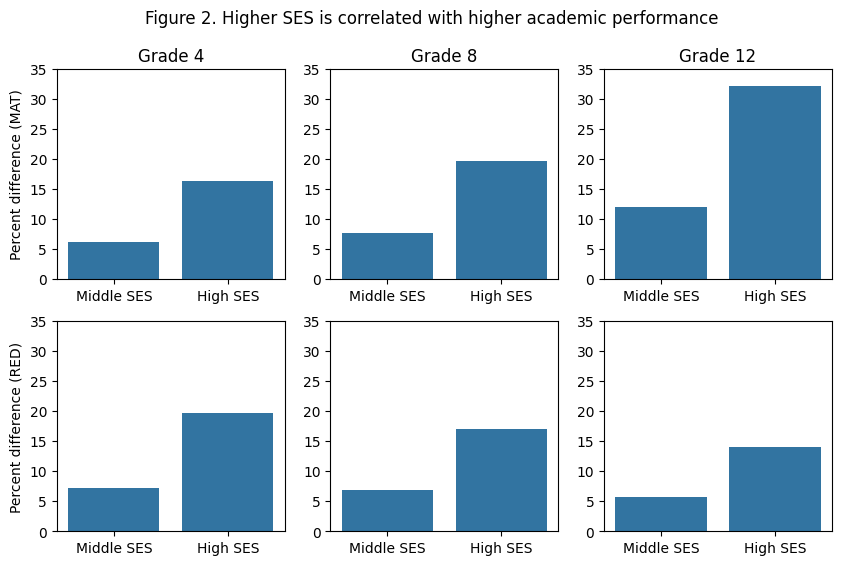

In [ ]:
fig4, ax4 = plt.subplots(2,3, figsize = (10,6))

for i in range(h1):
  for j in range(w1):
    if i == 0:
      sns.barplot(ses_comparison_df.query(f"subject == 'MAT' and Cohort == {j + 1}"),
                  x = "focalValLabel", y = "pct_gap", ax = ax4[i][j], errorbar=None)
      ax4[i][j].set_title(f"Grade {c_to_g[j+1]}")
      if j == 0:
        ax4[i][j].set_ylabel("Percent difference (MAT)")
      else:
        ax4[i][j].set_ylabel(None)
    else:
      sns.barplot(ses_comparison_df.query(f"subject == 'RED' and Cohort == {j + 1}"),
                  x = "focalValLabel", y = "pct_gap", ax = ax4[i][j], errorbar=None)
      if j == 0:
        ax4[i][j].set_ylabel("Percent difference (RED)")
      else:
        ax4[i][j].set_ylabel(None)
    ax4[i][j].set_xlabel(None)
    ax4[i][j].set_ylim(0, 35)

  fig4.suptitle("Figure 2. Higher SES is correlated with higher academic performance")
  pass

According to Table 2, all 12 comparisons resulted in statistically significant higher scores for students in Middle and High SES categories than students in the Low SES category. An interesting trend in Figure 2 is that the difference between groups increases as grades increase for the math assessment (denoted with 'MAT'), while the differences decrease as grades increase for the reading assessment (denoted with 'RED'). This may be because reading and comprehension is practiced by students everyday, especially online and on social media, whereas math is mostly practiced in the classroom and more of a focus for students interested in college. Reading is also a skill that crosses all subject areas (e.g. social studies, science) that becomes especially more important in later grades.

### Differences Across States

In the U.S., education is mostly controlled at the state level. This creates a rich environment to compare all 50 states and see which states are high performers and which states are lagging.

In [ ]:
# Get list of all states in correct format
state_keys = list(states.keys())
national_keys = list(national.keys())
all_keys = national_keys + state_keys
all_keys_str = ",".join(all_keys)

states_NAEP_ls = []
# Commented out due to lags in API. For project replication, the data will be
# downloaded from a csv on github.
"""
for s in subjects:
  for c in c_to_g:
    c = str(c)
    # get assessments
    for a in available_tests[c][s].keys():

# The following lines of commented code were used to save separate dataframes as
# API requests would stall through iterations.
#      if (s == "mathematics" and a in ["1990R2", "2005R3"]) or (s == "reading" and c in ["1", "2"]):
#        pass
#      else:

      years = available_tests[c][s][a]
      years_str = ",".join(years)
      subscale = list(subscale_values[s][a])[0]
      print(f"s = {s}, c = {c}, a = {a}, years = {years_str}")
      states_NAEP_ls.append(get_education_statistics("data", s, c, subscale, "TOTAL",
                                                    all_keys_str, "MN:MN,SD:SD",
                                                      years_str)
      )
#states_NAEP_df = pd.concat(states_NAEP_ls)
#states_NAEP_df.to_csv("states_NAEP_df")
#states_NAEP_df2 = pd.concat(states_NAEP_ls)
#states_NAEP_df2.to_csv("states_NAEP_df2")
#states_NAEP_df3 = pd.concat(states_NAEP_ls)
#states_NAEP_df3.to_csv("states_NAEP_df3")
#states_NAEP_final_ls = [states_NAEP_df, states_NAEP_df2, states_NAEP_df3]
#states_NAEP_final_df = pd.concat(states_NAEP_final_ls)
#states_NAEP_final_df.to_csv("states_NAEP_final_df.csv")
"""
states_NAEP_final_df = pd.read_csv("https://raw.githubusercontent.com/DLPsamuel/Education_Data_Project/refs/heads/main/states_NAEP_final_df.csv")

In [ ]:
states_NAEP_final_df.describe()

,Unnamed: 0,year,Cohort,grade,varValue,value,isStatDisplayable,errorFlag
count,7668.000000,7668.000000,7668.000000,7668.000000,7668.0,7668.000000,7668.000000,7668.000000
mean,633.049296,2007.352113,1.915493,7.661972,1.0,440.014593,0.650756,113.055816
std,432.863095,10.314206,0.800518,3.202073,0.0,418.561718,0.476762,152.950927
min,0.000000,1990.000000,1.000000,4.000000,1.0,23.200585,0.000000,0.000000
25%,273.000000,1998.000000,1.000000,4.000000,1.0,37.388919,0.000000,0.000000
50%,566.500000,2009.000000,2.000000,8.000000,1.0,253.262592,1.000000,0.000000
75%,934.000000,2015.000000,3.000000,12.000000,1.0,999.000000,1.000000,320.000000
max,1727.000000,2024.000000,3.000000,12.000000,1.0,999.000000,1.000000,328.000000


The max and 75 percentile values are 999, which is above the assessment's maximum score of 500. This value is entered instead of a `null` value, so they need to be converted to properly reflect available data.

In [ ]:
# Clean Data
# All 999 values should be null
states_NAEP_final_df.loc[states_NAEP_final_df["value"] > 990, "value"] = np.nan

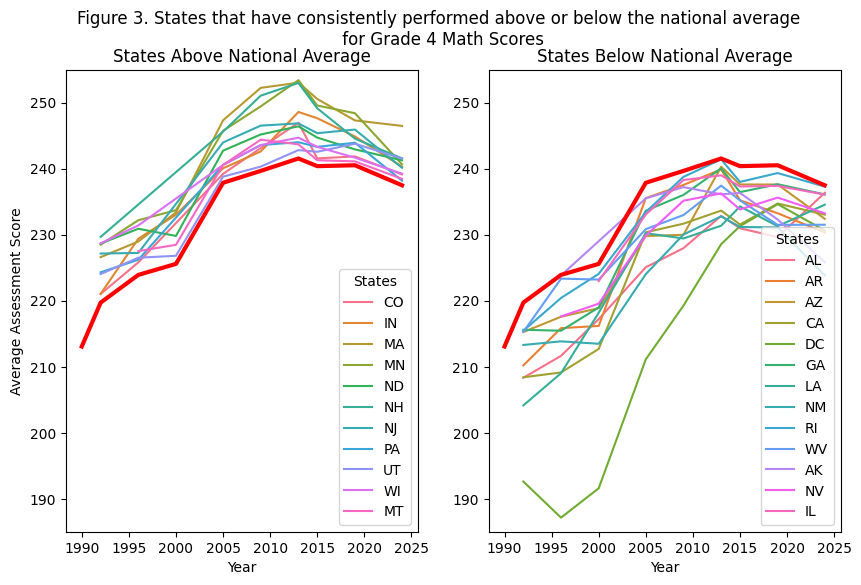

In [ ]:
# Group by state
states_NAEP_math_4 = (states_NAEP_final_df.query("subject == 'MAT' and stattype == 'MN:MN' and jurisdiction not in ['NT', 'NP', 'NR'] and grade == 4"))
national_NAEP_math_4 = (states_NAEP_final_df.query("subject == 'MAT' and stattype == 'MN:MN' and jurisdiction == 'NT' and grade == 4"))
national_NAEP_math_4 = national_NAEP_math_4.rename(columns={"value": "value_NT"})

# remove NaN values
states_NAEP_math_4 = states_NAEP_math_4.dropna(subset="value")

# find states that always landed above the average
states_NAEP_math_4_merge = states_NAEP_math_4.merge(national_NAEP_math_4[["year", "value_NT"]], on = "year", how = "left")
states_NAEP_math_4_merge["NT_comp"] = np.where(states_NAEP_math_4_merge["value"] >= states_NAEP_math_4_merge["value_NT"],
                                             "above", "below")
# get list of states that have below or above, add the names to sets
not_always_above = set()
not_always_below = set()
for i in range(len(states_NAEP_math_4_merge)):
  st = str(states_NAEP_math_4_merge.iloc[i]["jurisdiction"])
  if states_NAEP_math_4_merge.iloc[i]["NT_comp"] == "below":
    not_always_above.add(st)
  elif states_NAEP_math_4_merge.iloc[i]["NT_comp"] == "above":
    not_always_below.add(st)
states_set = set(states)
always_above = states_set.difference(not_always_above)
always_below = states_set.difference(not_always_below)

# filter for always above/below states
math_4_above = states_NAEP_math_4_merge[states_NAEP_math_4_merge["jurisdiction"].isin(always_above)]
math_4_below = states_NAEP_math_4_merge[states_NAEP_math_4_merge["jurisdiction"].isin(always_below)]

# get list of states that have below, add the

fig3, ax3 = plt.subplots(1,2, figsize = (10,6))

sns.lineplot(data=math_4_above, x = "year", y = "value", hue = "jurisdiction",
             ax = ax3[0])
sns.lineplot(data=national_NAEP_math_4, x = "year", y = "value_NT", ax = ax3[0],
             linewidth=3, color = 'r')
ax3[0].set_title("States Above National Average")
ax3[0].set_xlabel("Year")
ax3[0].set_ylabel("Average Assessment Score")
ax3[0].set_ylim(185, 255)

sns.lineplot(data=math_4_below, x = "year", y = "value", hue = "jurisdiction",
             ax = ax3[1])
sns.lineplot(data=national_NAEP_math_4, x = "year", y = "value_NT", ax = ax3[1],
             linewidth=3, color='r')
ax3[1].set_title("States Below National Average")
ax3[1].set_xlabel("Year")
ax3[1].set_ylabel(None)
ax3[1].set_ylim(185, 255)
legend = ax3[0].get_legend()
legend.set_title("States")
legend = ax3[1].get_legend()
legend.set_title("States")

fig3.suptitle("Figure 3. States that have consistently performed above or below \
the national average \n for Grade 4 Math Scores")
pass

There are a decent number of states that, since the beginning of the national assessment, have consistently performed  better (and worse) than average, according to available assessment data. This represents the total average, and does not distinguish for public school, so a future analysis on only public schools may affect results. Only 4th grade math was analyzed in this section.

Additionally, DC is more a metropolitan area than a state, which is likely why the scores are substantially different than that of other states. However, DC's scores have improved drastically in the last 5 years.

### State comparison of revenue  levels

The following metric is a prediction of revenue per pupil within a given state in a given year at four different U.S. Census district poverty levels. These predictions include state financial data in a regression that controls for population density, district size, and labor market costs. The SFID team recommends considering 30% as a high district poverty level, which can be considered having 85% free-/reduced-price lunch eligibility. In order to observe national trends, the average is taken over all states and D.C. for each year.

The `fairness` metric is the ratio between 30% district poverty and 0% district poverty for state and local revenue, aiming to capture by how much lower income districst receive more (or less) revenue compared to more affluent districts.

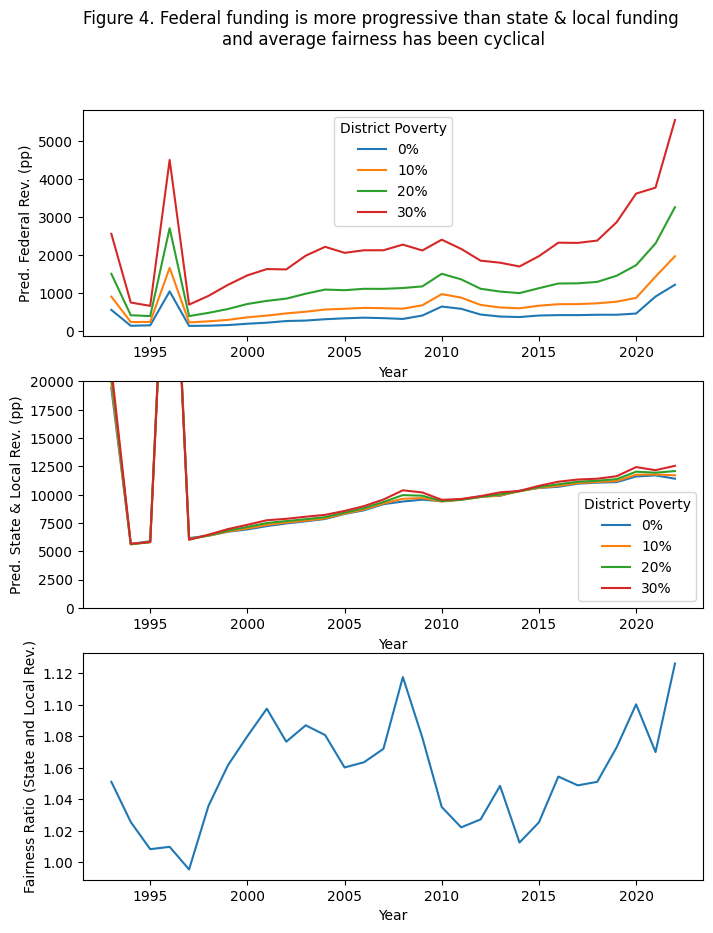

In [ ]:
# Find average per-pupil federal revenue
fedrev_vars = ["predicted_fedrevpp0_", "predicted_fedrevpp10_",
            "predicted_fedrevpp20_", "predicted_fedrevpp30_"]
fedrev_yr_df = sfid_df.groupby("year", as_index=False)[fedrev_vars].mean()

fedrev_yr_final_df = pd.melt(fedrev_yr_df, id_vars=["year"], value_vars=fedrev_vars,
                             var_name="fedrevpp_pct", value_name = "fedrevpp_value")
fedrev_yr_final_df["fedrevpp_pct"] = (fedrev_yr_final_df["fedrevpp_pct"]
                                      .str.replace("predicted_fedrevpp", "")
                                      .str.replace("_", "%")
                                      )

# Find average per-pupil state and local revenue
slocrev_vars = ["predicted_slocrev0_", "predicted_slocrev10_", "predicted_slocrev20_",
                "predicted_slocrev30_"]
slocrev_yr_df = sfid_df.groupby("year", as_index=False)[slocrev_vars].mean()

slocrev_yr_final_df = pd.melt(slocrev_yr_df, id_vars=["year"], value_vars=slocrev_vars,
                              var_name="slocrevpp_pct", value_name = "slocrevpp_value" )
slocrev_yr_final_df["slocrevpp_pct"] = (slocrev_yr_final_df["slocrevpp_pct"]
                                        .str.replace("predicted_slocrev", "")
                                        .str.replace("_", "%")
                                        )

# Find national average of fairness
fairness_yr_df = sfid_df.groupby("year", as_index=False)["fairness"].mean()

# Plot results
fig2, ax2 = plt.subplots(3, 1, figsize = (8,10))

sns.lineplot(data = fedrev_yr_final_df, x = "year", y = "fedrevpp_value",
             hue = "fedrevpp_pct", ax = ax2[0])
ax2[0].set_ylabel("Pred. Federal Rev. (pp)")
ax2[0].set_xlabel("Year")
legend = ax2[0].get_legend()
legend.set_title("District Poverty")

sns.lineplot(data = slocrev_yr_final_df, x = "year", y = "slocrevpp_value",
             hue = "slocrevpp_pct", ax = ax2[1])
ax2[1].set_ylim(0, 20000)
ax2[1].set_ylabel("Pred. State & Local Rev. (pp)")
ax2[1].set_xlabel("Year")
legend = ax2[1].get_legend()
legend.set_title("District Poverty")

sns.lineplot(data = fairness_yr_df, x = "year", y = "fairness", ax = ax2[2])
ax2[2].set_ylabel("Fairness Ratio (State and Local Rev.)")
ax2[2].set_xlabel("Year")

fig2.suptitle("Figure 4. Federal funding is more progressive than state & local \
funding \nand average fairness has been cyclical")
pass

It is clear from Figure 4. that the federal government revenue per pupil (pp) is alocated in a much more progressive manner than state and local revenue, as demonstrated by the higher funding amounts for higher district poverty levels. While state and local revenue per pupil has steadily increased over time, there has been a dramatic increase in federal education spending over the last five years.

According to the SFID team, the high spikes in values are due to missing state information from those years, however it was taken into consideration across all states, and thus the fairness calculation and comparison across other states for that year are valid.

It is also interesting to observe the rise and fall in state average fairness, rising in the 2000's, staying low in the 2010's, then gradually increasing after 2015.

### Correlation between resources and assessment outcomes by state

By comparing state assessment achievement and state finance indicators, this analysis will try to uncover potential correlations between the two. The indicators analyzed are the following:

* `effort`: Total state expenditures on K-12 schools as a proportion of state economic capacity, measured using the Gross State Product
* `fairness_curexpp`: Spending progressivity (ratio of predicted current spending per pupil at 30% district poverty to 0% district poverty)
* `fairness_tchph`: Staffing progressivity (ratio of predicted teachers per 100 pupils at 30% district poverty to 0% district poverty)
* `predicted_slocrev`: Predicted state and local revenue at various district poverty levels

All indicators are compared to their respective state's assessment scores for each year that has available data.

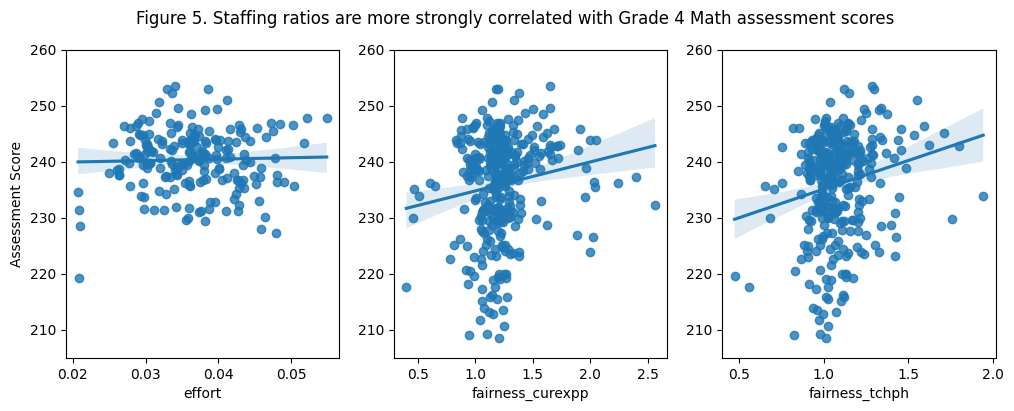

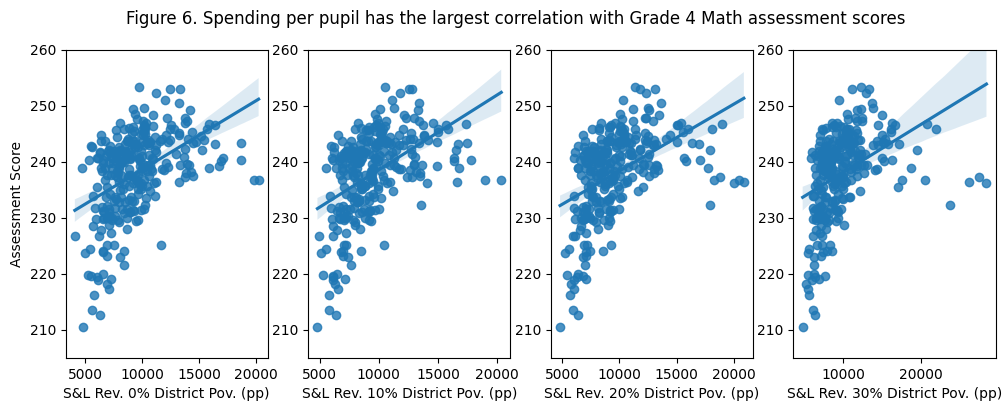

In [ ]:
# merge sfid (only the years that exist) with naep for math in 4th grade
states_NAEP_math_4_clean = states_NAEP_math_4[["year", "jurisdiction", "value"]]
sfid_clean = sfid_df[["year", "stabbr", "region4", "effort", "fairness_curexpp", "fairness_tchph",
                      "predicted_slocrev0_", "predicted_slocrev10_", "predicted_slocrev20_", "predicted_slocrev30_"]]
corr_analysis_df = pd.merge(states_NAEP_math_4_clean, sfid_clean, how="inner", left_on=["year", "jurisdiction"], right_on=["year", "stabbr"])

# keep only variables that have values
fig5, ax5 = plt.subplots(1,3, figsize = (12,4))

corr_variables = ["effort", "fairness_curexpp", "fairness_tchph"]
var_corr_v = []
var_p_value = []
var_len = []

for i in range(len(corr_variables)):
  current_df = corr_analysis_df.dropna(subset=corr_variables[i])
  sns.regplot(data=current_df, x = corr_variables[i], y = "value", ax = ax5[i])
  corr_v, p_value = stats.pearsonr(current_df[corr_variables[i]], current_df["value"])
  var_corr_v.append(corr_v)
  var_p_value.append(p_value)
  var_len.append(len(current_df))
  ax5[i].set_ylim(205, 260)
  if i == 0:
    ax5[i].set_ylabel("Assessment Score")
  else:
    ax5[i].set_ylabel(None)

fig5.suptitle("Figure 5. Staffing ratios are more strongly correlated with Grade \
4 Math assessment scores")

var_corr_table = pd.DataFrame({"variable": corr_variables, "corr_v": var_corr_v, "p_value": var_p_value, "N": var_len})

# plot for state and local revenues
fig6, ax6 = plt.subplots(1, 4, figsize=(12,4))

slocrev = ["predicted_slocrev0_", "predicted_slocrev10_", "predicted_slocrev20_", "predicted_slocrev30_"]
slocrev_corr_df = corr_analysis_df.query("year != 1996")
slocrev_p_value = []
slocrev_corr_v = []
slocrev_len = []
slocrev_labels = []

for i in range(len(slocrev)):
  current_df = slocrev_corr_df.dropna(subset=slocrev[i])
  sns.regplot(data=current_df, x = slocrev[i], y = "value", ax = ax6[i])
  corr_v, p_value = stats.pearsonr(current_df[slocrev[i]], current_df["value"])
  slocrev_p_value.append(p_value)
  slocrev_corr_v.append(corr_v)
  ax6[i].set_ylim(205, 260)
  slocrev_len.append(len(current_df))
  # update labels
  label = slocrev[i].replace("predicted_slocrev", "S&L Rev. ")
  label = label.replace("_", "% District Pov. (pp)")
  slocrev_labels.append(label)
  ax6[i].set_xlabel(label)
  if i == 0:
    ax6[i].set_ylabel("Assessment Score")
  else:
    ax6[i].set_ylabel(None)


fig6.suptitle("Figure 6. Spending per pupil has the largest correlation with \
Grade 4 Math assessment scores")

slocrev_corr_table = pd.DataFrame({"label": slocrev_labels, "corr_v": slocrev_corr_v, "p_value": slocrev_p_value, "N": slocrev_len})



In [ ]:
print("Table 3. Correlation between state resource indicators and their \n Grade \
4 Math assessment scores")
display(var_corr_table)

Table 3. Correlation between state resource indicators and their 
 Grade 4 Math assessment scores


,variable,corr_v,p_value,N
0,effort,0.030361,0.667187,203
1,fairness_curexpp,0.153833,0.005379,326
2,fairness_tchph,0.193461,0.000443,326


In [ ]:
print("Table 4. Correlation between state and local revenue at various district \n \
poverty levels and their Grade 4 Math assessment scores")
display(slocrev_corr_table)

Table 4. Correlation between state and local revenue at various district 
 poverty levels and their Grade 4 Math assessment scores


,label,corr_v,p_value,N
0,S&L Rev. 0% District Pov. (pp),0.462878,1.738283e-16,284
1,S&L Rev. 10% District Pov. (pp),0.487992,2.128076e-18,284
2,S&L Rev. 20% District Pov. (pp),0.467135,8.452783e-17,284
3,S&L Rev. 30% District Pov. (pp),0.401050,2.126361e-12,284


Only Grade 4 Math scores were compared for this analysis. Figure 5 demonstrates that there is no correlation between a state's fiscal effort and assessment scores, but there are small and significant (p-values less than 0.05 according to Table 3) correlations for a state's expenditure fairness and for the fairness of staffing ratios, which is 0.15 and 0.19 respectively.

Figure 6 shows that there is a strong correlation between revenue per pupil at the state and local level, and appears to be less significant above a certain level (approximately $15,000 per pupil). According to Table 4, the strongest correlation is for state and local revenue levels at the 10% district poverty level, and the weakest correlation is for revenue levels at the highest (30%) district poverty level. This means there is a stronger relationship between how much is allocated for higher income districts and the state's test scores than lower income districts. It would be more ideal to compare spending in those districts with the test score outcomes in those districts, which can be pursued in future research.

# Conclusion & Recommendations

After a brief analysis of state assessment scores and financial indicators, there are a few takeaways that can guide public education policymaking and research moving forward. There are, of course, limitations with this analysis that need to be addressed, as well as future opportunities for further investigation.

## Takeaways

The first takeaway is that there is a significant difference in state average assessment scores for mathematics and reading between SES groups, with differences between the highest and lowest groups at 15%-30%. The differences increase throughout grades in mathematics, but decrease throughout grades in reading. This highlights the need for improved investment in mathematics for lower SES groups in order to create better equity for the U.S. education system.

Next, the report identified a group of states that performed consistently above the national average (CO, IN, MA, MN, ND, NH, NJ, PA, UT, WI, and MT) while also identifying a group of states (and DC) that performed consistently below the national average (AL, AR, AZ, CA, DC, GA, LA, NM, RI, WV, AK, NV, and IL).

Regarding state financial indicators, the report represented graphically the extent to which federal education revenue is progressive compared to state and local revenue, and how the national average of fairness of state and local revenue allocation has changed over time, representing a cyclical nature. The national ratio has been on the rise in the last 10 years, demonstrating a shift to more funding allocated for lower income districts.

Lastly, strong (~.45) positive correlations were observed between state and local revenue per pupil and state assessment scores. Significant positive correlations, although weaker (~.15) are observed between both expenditure fairness and staffing ratios fairness with state assessment scores.

## Limitations

One main limitation of the anlysis is that certain trends were only observed for 4th grade math due to time constraints. This only captures a small fraction of state educational performance, however it does give a specific view to analytical elementary education.

The report also looked at state information, which is composed of widely diverse districts (e.g. urban, rural). Comparing district finance indicators with their respective assessment scores would provide better insight into which financial levers leaders could pull to best improve their education system.

A third limitation of this report is that the NAEP assessment is just one way to measure a student's aptitude, and includes imperfections. The SFID numbers, while rigorously calculated, are still estimates from models and could contain errors or assumptions that manipulate the trends observed in this report.

## Suggestions for future research

For assessment scores, the only variable anlayzed for differences was socioeconomic status. Future research can explore the difference between regions (e.g. city, rural), gender, and race and ethnicity.
Focused attention should be devoted to the higher performing states to understand how they excel, as well as to the lower performing states to understand why they are lagging behind.
These same trends should be explored across more grades and subject areas than just 4th grade math, and more finance variables (e.g. teacher compensation).
Lastly, more segmented analysis between private and public outcomes should be compared to remove any bias from this omitted variable.

## Conclusion

The future of public education depends on the decisions made today. There are many urgent parts of the system that need improvement. The more decisions are guided by thoughtful analysis, the better chance the nation has to improve educational and life outcomes for all.

# Citations

Baker, Bruce D., Di Carlo, Matthew, Srikanth, Ajay, and Weber, Mark A. 2025. School Finance Indicators Database: State Indicators Database 2025 (7th Release). Washington, DC: Albert Shanker Institute. Retrieved from: http://www.schoolfinancedata.org.  


U.S. Department of Education. Institute of Education Sciences, National Center for Education Statistics, National Assessment of Educational Progress (NAEP)